## Data Sources

This project uses two public tennis datasets:

- Jeff Sackmann’s point-by-point dataset
- Jeff Sackmann’s ATP match dataset

The point-by-point dataset provides the sequence of points within each match, while the ATP dataset provides contextual information such as surface, tournament level, and player rankings.

## Data Enrichment

The original point-by-point data was enriched with match-level ATP information.  

Added features include:
- surface (clay, hard, grass)
- player ranking
- opponent ranking
- rank difference
- tournament information

This enrichment step is important because it makes the analysis more meaningful than using raw point sequences alone.

## Hypotheses

The main hypothesis of this project is that losing a break point leads to a short-term decline in performance.

- **H0:** The mean performance drop after losing a break point is equal to zero.
- **H1:** The mean performance drop after losing a break point is below zero.


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [43]:
df = pd.read_csv("breakpoint_events.csv")
df.head()

,match_id,date,tourney_name,surface,tourney_level,pressure_level,round,player,opponent,set_no,...,match_winner,rank_diff,is_underdog,won_match,pbpp_3,pd_3,pbpp_6,pd_6,pbpp_12,pd_12
0,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Gilles Muller,Edouard Roger-Vasselin,2,...,Gilles Muller,-70.0,0,1,1.000000,0.452736,0.833333,0.286070,0.833333,0.286070
1,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Edouard Roger-Vasselin,Gilles Muller,3,...,Gilles Muller,70.0,1,0,0.666667,0.213930,0.500000,0.047264,0.333333,-0.119403
2,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Edouard Roger-Vasselin,Gilles Muller,3,...,Gilles Muller,70.0,1,0,0.333333,-0.119403,0.333333,-0.119403,0.416667,-0.036070
3,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Edouard Roger-Vasselin,Gilles Muller,3,...,Gilles Muller,70.0,1,0,0.000000,-0.452736,0.333333,-0.119403,0.416667,-0.036070
4,7031687,2015-01-05,Chennai,Hard,A,lower,R32,Robin Haase,Borna Coric,1,...,Borna Coric,-15.0,0,0,0.333333,-0.028369,0.166667,-0.195035,0.083333,-0.278369


In [44]:
df[["pbpp_3", "pbpp_6", "pbpp_12", "pd_3", "pd_6", "pd_12"]].isna().sum()

,0
pbpp_3,682
pbpp_6,1110
pbpp_12,2523
pd_3,682
pd_6,1110
pd_12,2523


In [45]:
# Example structure (simplified)

events = pd.read_csv("breakpoint_events.csv")

events["pd_3"] = events["pbpp_3"] - events["baseline_win_rate"]
events["pd_6"] = events["pbpp_6"] - events["baseline_win_rate"]
events["pd_12"] = events["pbpp_12"] - events["baseline_win_rate"]

## Break Point Identification

A break point is defined as a situation where the receiving player can win the game on the next point.

A lost break point event occurs when:
- the player is the receiver
- the score indicates break point
- the player loses the point

After each lost break point, the next k points (k = 3, 6, 12) are tracked.

In [46]:
print("Number of rows:", len(df))
print("Columns:")
print(df.columns)

Number of rows: 36267
Columns:
Index(['match_id', 'date', 'tourney_name', 'surface', 'tourney_level',
       'pressure_level', 'round', 'player', 'opponent', 'set_no', 'game_no',
       'point_index', 'player_rank', 'opponent_rank', 'baseline_win_rate',
       'match_winner', 'rank_diff', 'is_underdog', 'won_match', 'pbpp_3',
       'pd_3', 'pbpp_6', 'pd_6', 'pbpp_12', 'pd_12'],
      dtype='object')


### Missing Values

A small number of missing values appear in the PBPP and PD variables.  
This happens because some break-point events do not have enough following points to compute the selected window completely.

To avoid invalid statistical results, missing values were removed before running the hypothesis tests.

In [47]:
events = events.dropna(subset=["pbpp_3", "pbpp_6", "pbpp_12"])
events = events.drop_duplicates()

## Data Cleaning

- Rows with missing PBPP values are removed
- These occur when fewer than k points remain in the match
- Duplicate rows are removed

## Project Overview

This notebook presents the April 14 milestone of my DSA210 term project.  
The goal is to examine whether professional tennis players experience a short-term performance decline after losing break points.

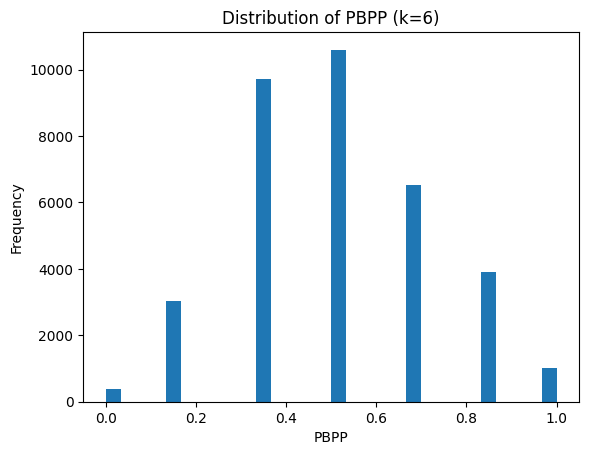

In [48]:
plt.hist(df["pbpp_6"], bins=30)
plt.title("Distribution of PBPP (k=6)")
plt.xlabel("PBPP")
plt.ylabel("Frequency")
plt.show()

### Interpretation of PBPP Distribution

PBPP values are mostly concentrated around the middle range, suggesting that after losing a break point, players often win a moderate share of the following points.  
This gives an initial view of how players perform immediately after high-pressure moments.

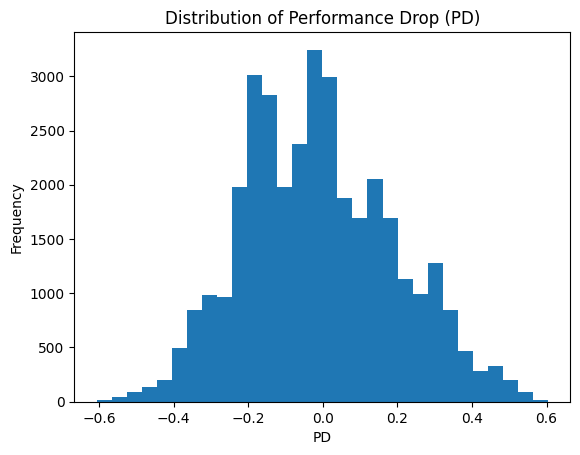

In [49]:
plt.hist(df["pd_6"], bins=30)
plt.title("Distribution of Performance Drop (PD)")
plt.xlabel("PD")
plt.ylabel("Frequency")
plt.show()

### Interpretation of Performance Drop

The PD distribution appears slightly shifted below zero.  
This suggests that players may perform somewhat worse than their usual baseline after losing a break point.

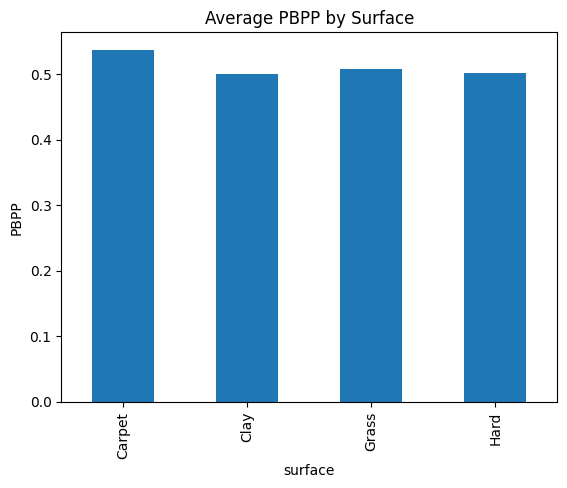

In [50]:
df.groupby("surface")["pbpp_6"].mean().plot(kind="bar")
plt.title("Average PBPP by Surface")
plt.ylabel("PBPP")
plt.show()

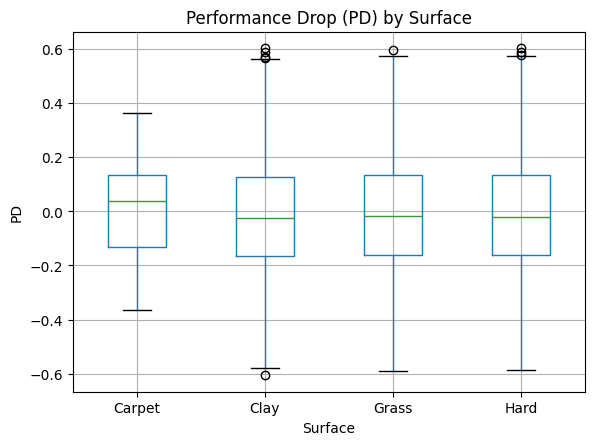

In [54]:
df.boxplot(column="pd_6", by="surface")
plt.title("Performance Drop (PD) by Surface")
plt.suptitle("")
plt.xlabel("Surface")
plt.ylabel("PD")
plt.show()

### Interpretation of PD by Surface

This boxplot shows how performance drop (PD) varies across different court surfaces.
The median PD values are generally below zero, which supports the idea that players tend to perform worse after losing a break point.
There may be some variation across surfaces, but the overall pattern remains negative.

In [51]:
pd6 = df["pd_6"].dropna()
t_stat, p_value = stats.ttest_1samp(pd6, 0)
print("t-statistic:", t_stat)
print("p-value:", p_value)
print("Mean PD:", pd6.mean())

t-statistic: -9.108118734675159
p-value: 8.812349193048484e-20
Mean PD: -0.009850827223298516


### Hypothesis Test Result

After removing missing values, the one-sample t-test on `pd_6` produced a statistically significant result (p < 0.05).  
The mean value of `pd_6` is below zero, which indicates that players tend to perform worse than their baseline after losing a break point.

The mean value of PD is below zero, which confirms that the performance after losing a break point is lower than the baseline performance.

The number of observations used in the test is sufficiently large, which increases the reliability of the statistical result.

This finding supports the main hypothesis of the project: lost break points are associated with a short-term decline in performance.


In [52]:
for k in [3, 6, 12]:
    col = f"pd_{k}"
    vals = df[col].dropna()
    t_stat, p_value = stats.ttest_1samp(vals, 0)
    print(f"{col}:")
    print("  Number of valid observations:", len(vals))
    print("  Mean:", vals.mean())
    print("  t-statistic:", t_stat)
    print("  p-value:", p_value)
    print()

pd_3:
  Number of valid observations: 35585
  Mean: -0.07940550844288813
  t-statistic: -51.6941057983034
  p-value: 0.0

pd_6:
  Number of valid observations: 35157
  Mean: -0.009850827223298516
  t-statistic: -9.108118734675159
  p-value: 8.812349193048484e-20

pd_12:
  Number of valid observations: 33744
  Mean: -0.006805331839019038
  t-statistic: -9.845774312295076
  p-value: 7.67403970090223e-23



### Robustness Across Different Windows

To check whether the result depends on a single short-term window, I repeated the same hypothesis test for `k = 3`, `k = 6`, and `k = 12`.

If the mean values remain below zero and the p-values are statistically significant across these different windows, this means the finding is robust.  
In other words, the performance decline is not limited to one arbitrary definition of “short term,” but appears consistently across multiple horizons.

In [53]:
groups = [group["pd_6"].dropna().values for _, group in df.groupby("surface")]
f_stat, p_value = stats.f_oneway(*groups)
print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 1.9333735401535643
p-value: 0.12177117630910833


### Surface Comparison Test

ANOVA is used to test whether average performance drop differs across surfaces.  
If the p-value is small, this suggests that court surface plays a role in short-term post-break-point performance.

## Conclusion

This analysis provides evidence that losing a break point is associated with a short-term drop in performance.  
The effect is visible in the descriptive analysis and supported by hypothesis testing.  

Most important conclusion from the finished analysis:

- the short-term drop is real
- it is strongest in the next 3 points
- it becomes much smaller by 6 and 12 points
- subgroup differences by surface and rank group are very small
- the effect stays stable under robustness checks

Surface differences may also play a role, although this effect should be explored further with broader data coverage.

